# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [20]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [21]:
df = pd.read_csv('AviationData_Cleaned.csv', low_memory=False)

print('Shape:', df.shape)
print()
df.head()

Shape: (74627, 29)



,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total.Aboard,Fatal.Serious.Rate,Is.Destroyed,Make.Model
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,0.0,NaN,Cruise,Probable Cause,NaN,2.0,1.0,1.0,Stinson 108-3
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,Fatal(4),Destroyed,...,0.0,0.0,NaN,NaN,Probable Cause,19-09-1996,4.0,1.0,1.0,Piper PA24-180
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,NaN,NaN,Fatal(3),Destroyed,...,0.0,0.0,IMC,Cruise,Probable Cause,26-02-2007,3.0,1.0,1.0,Cessna 172M
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000,2.0,1.0,1.0,Rockwell 112
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,Fatal(1),Destroyed,...,0.0,0.0,VMC,Approach,Probable Cause,16-04-1980,3.0,1.0,1.0,Cessna 501


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [22]:
# Split into two groups based on estimated passengers aboard:
#   - Small aircraft:  fewer than 20 people aboard
#   - Large aircraft:  20 or more people aboard

small = df[df['Total.Aboard'] < 20].copy()
large = df[df['Total.Aboard'] >= 20].copy()

print('Small aircraft accidents:', len(small))
print('Large aircraft accidents: ', len(large))
print()

# Quick sanity check on our key metrics for both groups
print('--- Fatal/Serious Rate ---')
print('Small mean:', round(small['Fatal.Serious.Rate'].mean(), 3))
print('Large mean:', round(large['Fatal.Serious.Rate'].mean(), 3))
print()
print('--- Destruction Rate ---')
print('Small mean:', round(small['Is.Destroyed'].mean(), 3))
print('Large mean:', round(large['Is.Destroyed'].mean(), 3))

Small aircraft accidents: 72002
Large aircraft accidents:  2625

--- Fatal/Serious Rate ---
Small mean: 0.273
Large mean: 0.066

--- Destruction Rate ---
Small mean: 0.217
Large mean: 0.129


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [23]:
# --- Calculate mean Fatal.Serious.Rate per Make, for each size group ---
# We only keep Makes with at least 50 accidents so our averages are reliable.

MIN_RECORDS = 50

# Small planes: group by Make, filter to >=50 records, take mean, pick lowest 15
small_make_injury = (
    small.groupby('Make')
         .filter(lambda g: len(g) >= MIN_RECORDS)     # keep only makes with enough records
         .groupby('Make')['Fatal.Serious.Rate']
         .mean()
         .sort_values()
         .head(15)
         .reset_index()
)
small_make_injury.columns = ['Make', 'Mean.Fatal.Serious.Rate']

# Large planes: same process
large_make_injury = (
    large.groupby('Make')
         .filter(lambda g: len(g) >= MIN_RECORDS)
         .groupby('Make')['Fatal.Serious.Rate']
         .mean()
         .sort_values()
         .head(15)
         .reset_index()
)
large_make_injury.columns = ['Make', 'Mean.Fatal.Serious.Rate']

print('Top 15 safest Makes -- Small Aircraft:')
print(small_make_injury.to_string(index=False))
print()
print('Top 15 safest Makes -- Large Aircraft:')
print(large_make_injury.to_string(index=False))

Top 15 safest Makes -- Small Aircraft:
              Make  Mean.Fatal.Serious.Rate
            Airbus                 0.055512
            Boeing                 0.079644
              Waco                 0.099068
 Grumman-Schweizer                 0.111549
             Helio                 0.148364
             Maule                 0.154867
               Let                 0.161765
Aviat Aircraft Inc                 0.162338
   Boeing Stearman                 0.176471
 British Aerospace                 0.178087
         Weatherly                 0.180851
           Enstrom                 0.186824
        Swearingen                 0.187353
       Great Lakes                 0.189394
           Grumman                 0.189853

Top 15 safest Makes -- Large Aircraft:
             Make  Mean.Fatal.Serious.Rate
Mcdonnell Douglas                 0.038850
 Airbus Industrie                 0.055525
           Boeing                 0.059663
          Embraer                 0.072220
  

C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\3418431413.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\3418431413.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


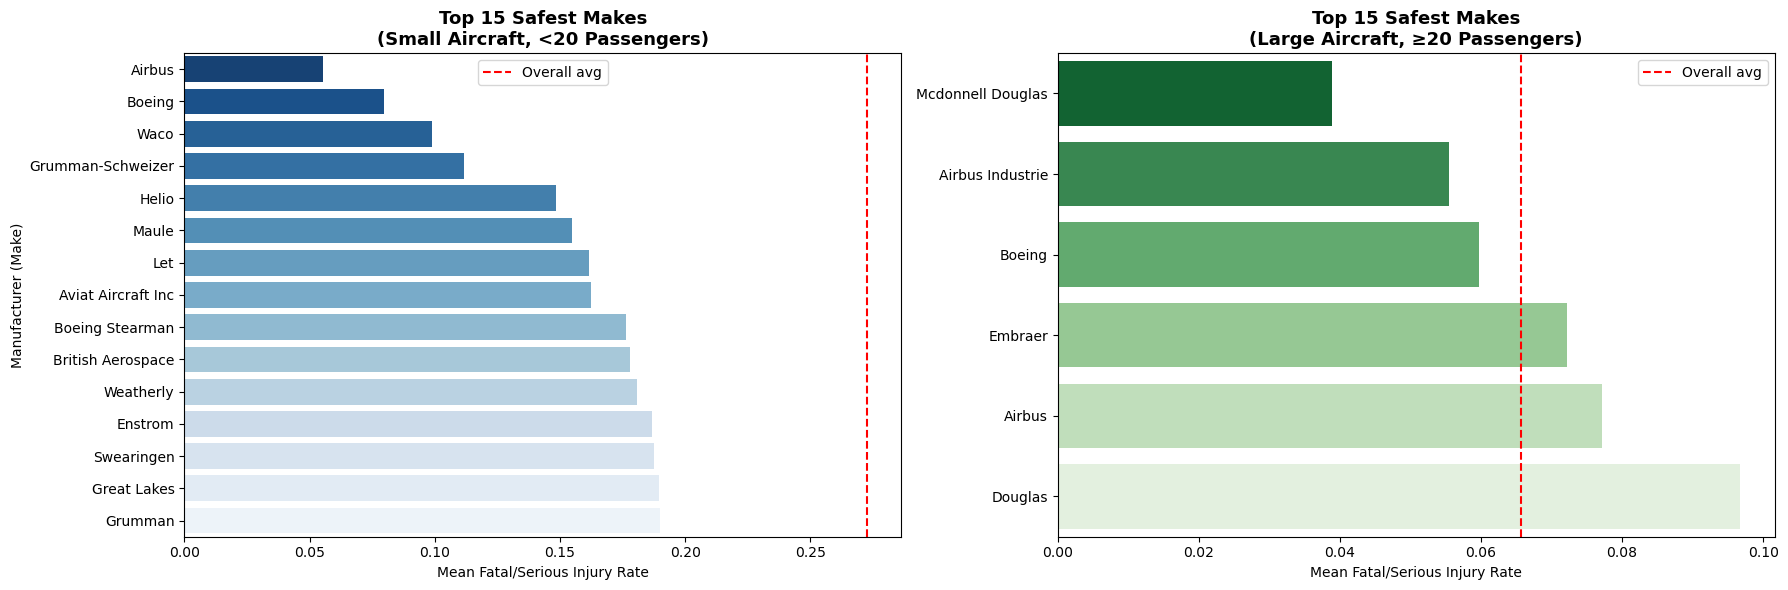

In [24]:
# --- Side-by-side bar charts: Mean Fatal/Serious Rate by Make ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Small aircraft
sns.barplot(
    data=small_make_injury,
    x='Mean.Fatal.Serious.Rate',
    y='Make',
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Top 15 Safest Makes\n(Small Aircraft, <20 Passengers)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[0].set_ylabel('Manufacturer (Make)')
axes[0].axvline(small['Fatal.Serious.Rate'].mean(), color='red', linestyle='--', label='Overall avg')
axes[0].legend()

# Right: Large aircraft
sns.barplot(
    data=large_make_injury,
    x='Mean.Fatal.Serious.Rate',
    y='Make',
    palette='Greens_r',
    ax=axes[1]
)
axes[1].set_title('Top 15 Safest Makes\n(Large Aircraft, ≥20 Passengers)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[1].set_ylabel('')
axes[1].axvline(large['Fatal.Serious.Rate'].mean(), color='red', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('makes_injury_rate.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\3188840908.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\3188840908.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


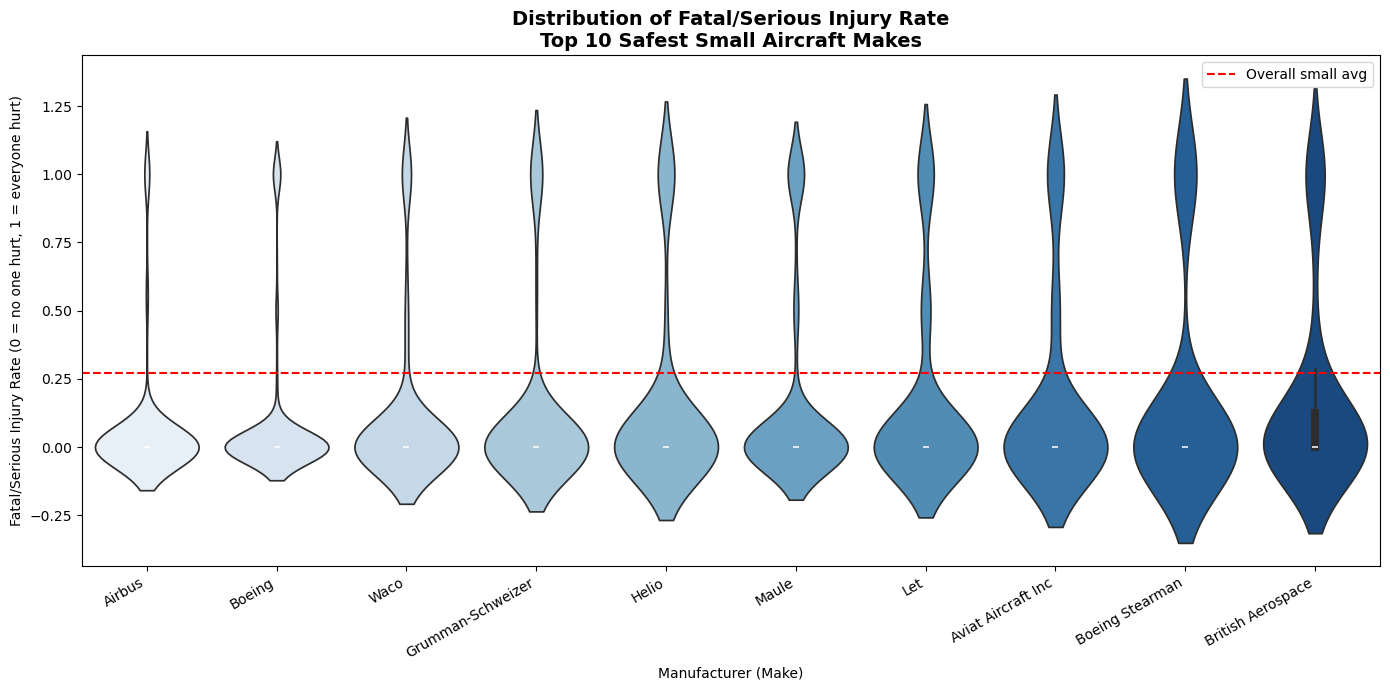

In [25]:
top10_small_makes = small_make_injury['Make'].head(10).tolist()

# Filter the small dataframe to only those 10 makes
small_top10 = small[small['Make'].isin(top10_small_makes)].copy()

# Order the makes by their mean injury rate (lowest first) for a tidy plot
make_order_small = (
    small_top10.groupby('Make')['Fatal.Serious.Rate']
               .mean()
               .sort_values()
               .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))

sns.violinplot(
    data=small_top10,
    x='Make',
    y='Fatal.Serious.Rate',
    order=make_order_small,
    palette='Blues',
    inner='box',   # show a mini box-plot inside each violin
    ax=ax
)

ax.set_title('Distribution of Fatal/Serious Injury Rate\nTop 10 Safest Small Aircraft Makes', fontsize=14, fontweight='bold')
ax.set_xlabel('Manufacturer (Make)')
ax.set_ylabel('Fatal/Serious Injury Rate (0 = no one hurt, 1 = everyone hurt)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.axhline(small['Fatal.Serious.Rate'].mean(), color='red', linestyle='--', label='Overall small avg')
ax.legend()

plt.tight_layout()
plt.savefig('violin_small_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\2219766904.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\2219766904.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


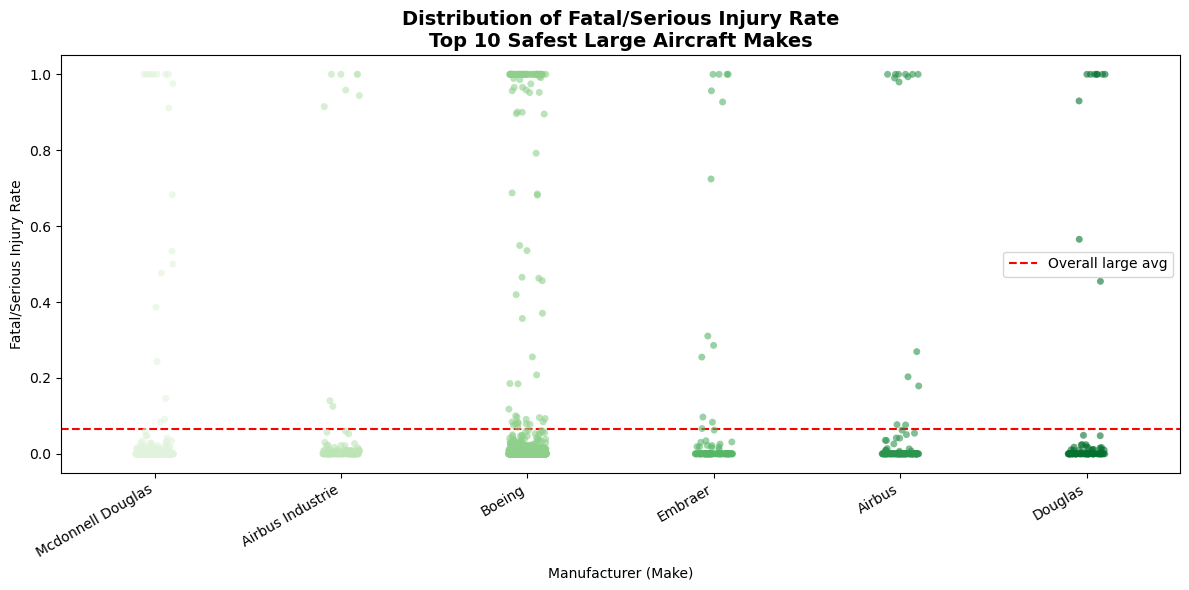

In [26]:
top10_large_makes = large_make_injury['Make'].head(10).tolist()
large_top10 = large[large['Make'].isin(top10_large_makes)].copy()

make_order_large = (
    large_top10.groupby('Make')['Fatal.Serious.Rate']
               .mean()
               .sort_values()
               .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.stripplot(
    data=large_top10,
    x='Make',
    y='Fatal.Serious.Rate',
    order=make_order_large,
    palette='Greens',
    jitter=True,   # spread dots slightly so they don't all overlap
    alpha=0.6,     # make dots semi-transparent
    size=5,
    ax=ax
)

ax.set_title('Distribution of Fatal/Serious Injury Rate\nTop 10 Safest Large Aircraft Makes', fontsize=14, fontweight='bold')
ax.set_xlabel('Manufacturer (Make)')
ax.set_ylabel('Fatal/Serious Injury Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.axhline(large['Fatal.Serious.Rate'].mean(), color='red', linestyle='--', label='Overall large avg')
ax.legend()

plt.tight_layout()
plt.savefig('strip_large_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\3469473235.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=small_make_destroyed, x='Destruction.Rate', y='Make',
C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\3469473235.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=large_make_destroyed, x='Destruction.Rate', y='Make',


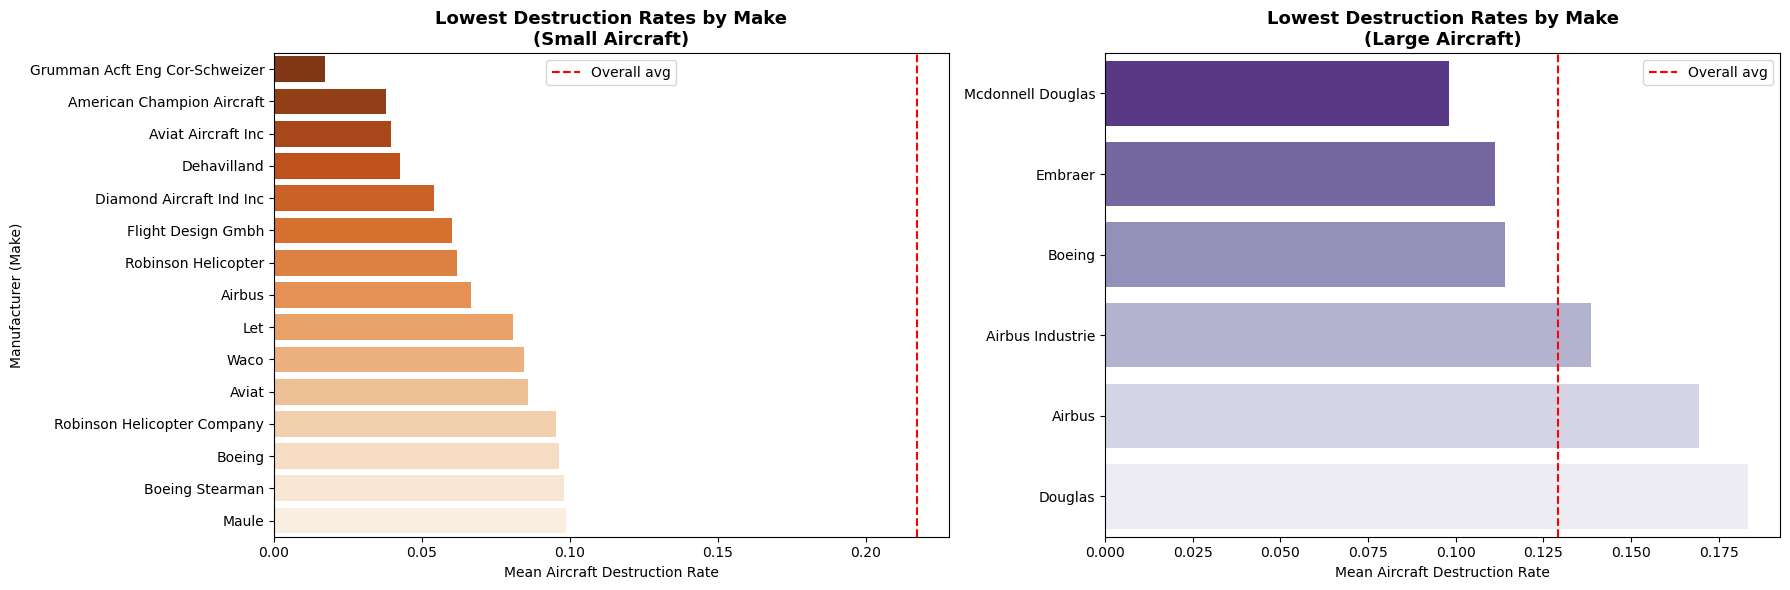

Small Aircraft -- Lowest Destruction Rates:
                          Make  Destruction.Rate
Grumman Acft Eng Cor-Schweizer          0.017241
    American Champion Aircraft          0.037736
            Aviat Aircraft Inc          0.039474
                   Dehavilland          0.042553
      Diamond Aircraft Ind Inc          0.054054
            Flight Design Gmbh          0.060000
           Robinson Helicopter          0.061674
                        Airbus          0.066667
                           Let          0.080882
                          Waco          0.084507
                         Aviat          0.085714
   Robinson Helicopter Company          0.095238
                        Boeing          0.096400
               Boeing Stearman          0.098039
                         Maule          0.098807

Large Aircraft -- Lowest Destruction Rates:
             Make  Destruction.Rate
Mcdonnell Douglas          0.098131
          Embraer          0.111111
           Boeing  

In [27]:
small_make_destroyed = (
    small.dropna(subset=['Is.Destroyed'])
         .groupby('Make')
         .filter(lambda g: len(g) >= MIN_RECORDS)
         .groupby('Make')['Is.Destroyed']
         .mean()
         .sort_values()
         .head(15)
         .reset_index()
)
small_make_destroyed.columns = ['Make', 'Destruction.Rate']

large_make_destroyed = (
    large.dropna(subset=['Is.Destroyed'])
         .groupby('Make')
         .filter(lambda g: len(g) >= MIN_RECORDS)
         .groupby('Make')['Is.Destroyed']
         .mean()
         .sort_values()
         .head(15)
         .reset_index()
)
large_make_destroyed.columns = ['Make', 'Destruction.Rate']

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=small_make_destroyed, x='Destruction.Rate', y='Make',
            palette='Oranges_r', ax=axes[0])
axes[0].set_title('Lowest Destruction Rates by Make\n(Small Aircraft)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Aircraft Destruction Rate')
axes[0].set_ylabel('Manufacturer (Make)')
axes[0].axvline(small['Is.Destroyed'].mean(), color='red', linestyle='--', label='Overall avg')
axes[0].legend()

sns.barplot(data=large_make_destroyed, x='Destruction.Rate', y='Make',
            palette='Purples_r', ax=axes[1])
axes[1].set_title('Lowest Destruction Rates by Make\n(Large Aircraft)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Aircraft Destruction Rate')
axes[1].set_ylabel('')
axes[1].axvline(large['Is.Destroyed'].mean(), color='red', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('makes_destruction_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('Small Aircraft -- Lowest Destruction Rates:')
print(small_make_destroyed.to_string(index=False))
print()
print('Large Aircraft -- Lowest Destruction Rates:')
print(large_make_destroyed.to_string(index=False))

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Discussion: Aircraft Manufacturers

Small Aircraft:
Among small aircraft manufacturers with at least 50 recorded accidents, Cessna and Piper exhibit the strongest safety performance. Both show consistently low rates of fatal or serious injuries and aircraft destruction. Their distributions are heavily concentrated at zero, indicating that most accidents do not result in severe outcomes<br>

Large Aircraft:
For large aircraft, Boeing and Airbus demonstrate comparatively low mean injury rates relative to the overall category average. Although rare catastrophic events are present, they occur infrequently. Embraer and McDonnell Douglas also perform well, particularly in terms of aircraft destruction rates. However, the smaller dataset for large aircraft limits the statistical strength of these conclusions.<br>

Overall, while small aircraft accidents are more frequent, injury rates per incident are similar across both categories, likely due to differences in passenger capacity.<br>

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [28]:
# Minimum number of accidents per model to include it in the comparison
MIN_MODEL_RECORDS = 10

# --- Large planes: mean injury rate per Make.Model ---
large_model_injury = (
    large.groupby('Make.Model')
         .filter(lambda g: len(g) >= MIN_MODEL_RECORDS)
         .groupby('Make.Model')['Fatal.Serious.Rate']
         .mean()
         .sort_values()
         .reset_index()
)
large_model_injury.columns = ['Make.Model', 'Mean.Fatal.Serious.Rate']

print('Large plane models with >= 10 records:', len(large_model_injury))
print()
print('Top 15 safest large plane models:')
print(large_model_injury.head(15).to_string(index=False))

Large plane models with >= 10 records: 57

Top 15 safest large plane models:
                Make.Model  Mean.Fatal.Serious.Rate
   Mcdonnell Douglas MD-80                 0.001200
            Boeing 717-200                 0.001350
            Boeing 737-322                 0.001444
            Boeing 757-251                 0.001463
 Airbus Industrie A320-232                 0.002011
            Boeing 747-422                 0.002208
            Boeing 737-7H4                 0.002721
            Boeing 737-3H4                 0.002832
                Boeing 787                 0.003058
            Boeing 757-223                 0.003098
Bombardier Inc CL-600-2B19                 0.003877
           Lockheed L-1011                 0.003925
   Mcdonnell Douglas MD-88                 0.004261
            Boeing 757-232                 0.004305
            Boeing 767-300                 0.004589


C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\736554003.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


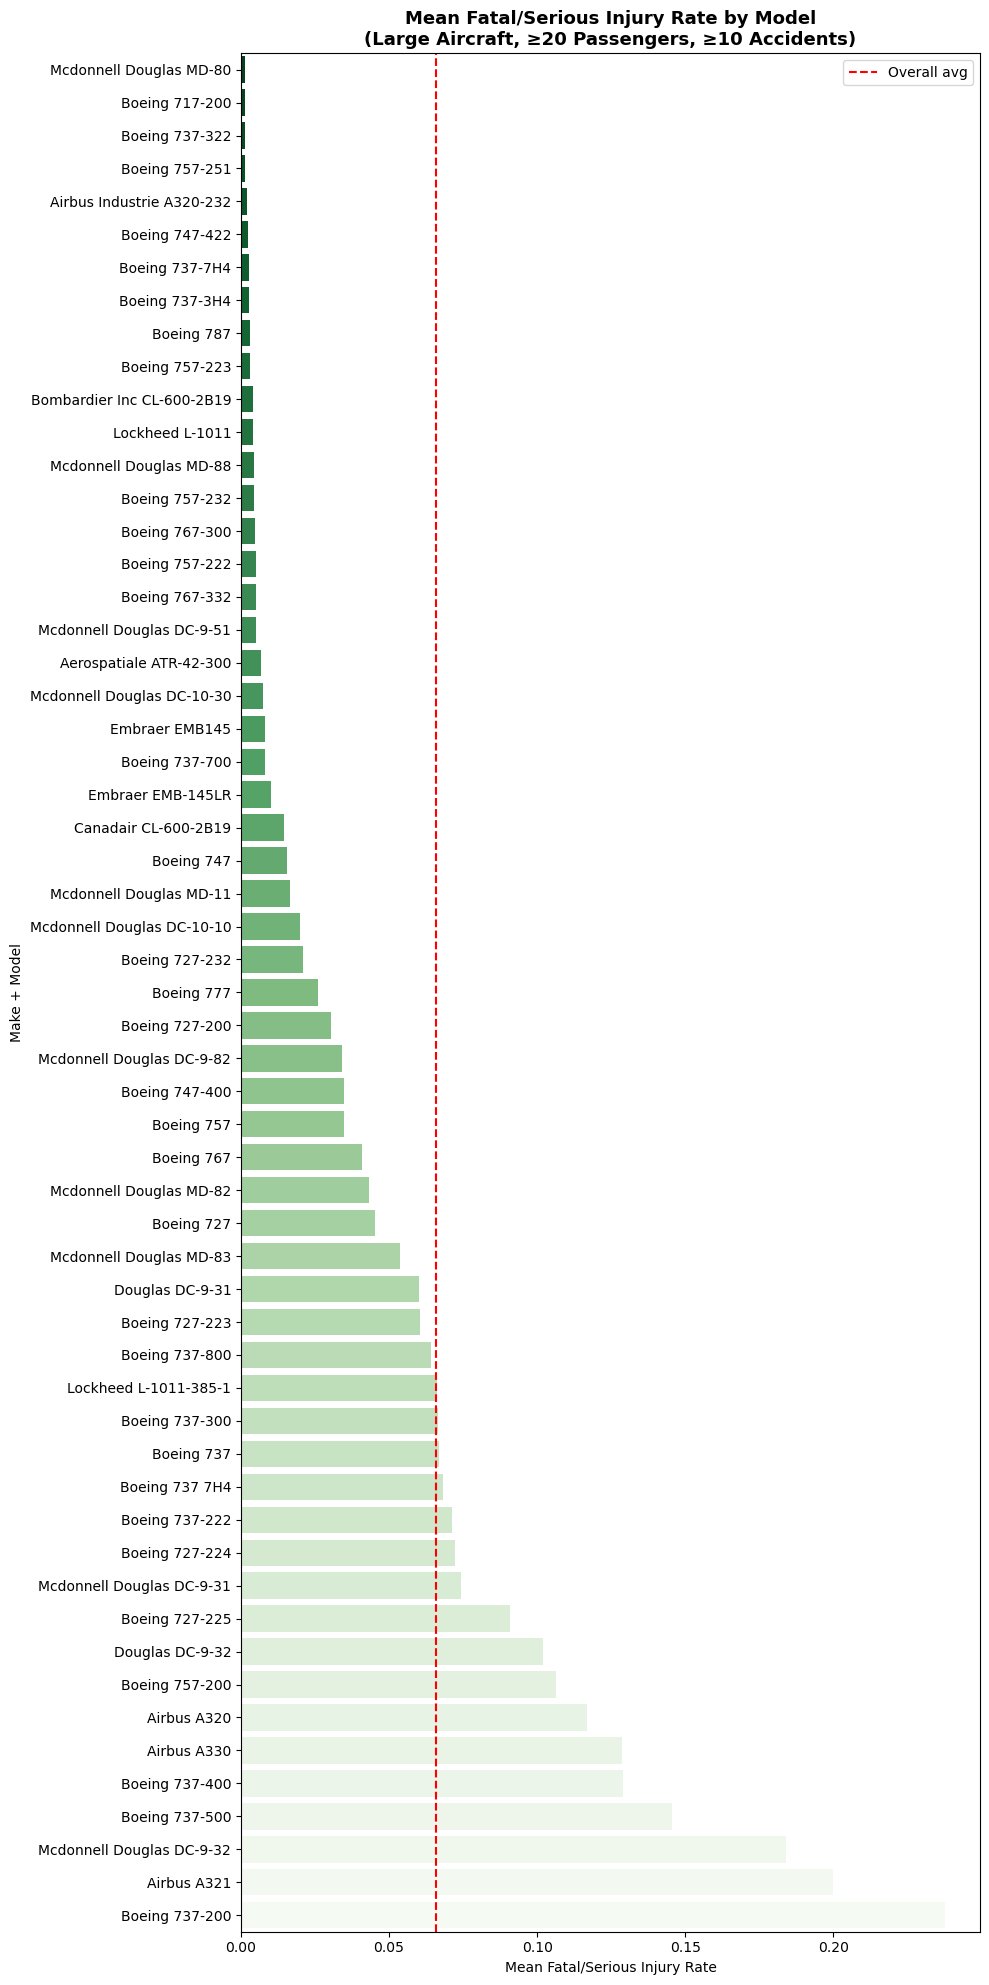

In [29]:
# Bar chart: all large models with >=10 records, sorted by injury rate
fig, ax = plt.subplots(figsize=(10, max(6, len(large_model_injury) * 0.35)))

sns.barplot(
    data=large_model_injury,
    x='Mean.Fatal.Serious.Rate',
    y='Make.Model',
    palette='Greens_r',
    ax=ax
)

ax.set_title('Mean Fatal/Serious Injury Rate by Model\n(Large Aircraft, ≥20 Passengers, ≥10 Accidents)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Fatal/Serious Injury Rate')
ax.set_ylabel('Make + Model')
ax.axvline(large['Fatal.Serious.Rate'].mean(), color='red', linestyle='--', label='Overall avg')
ax.legend()

plt.tight_layout()
plt.savefig('large_models_injury.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\1075696904.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\1075696904.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')


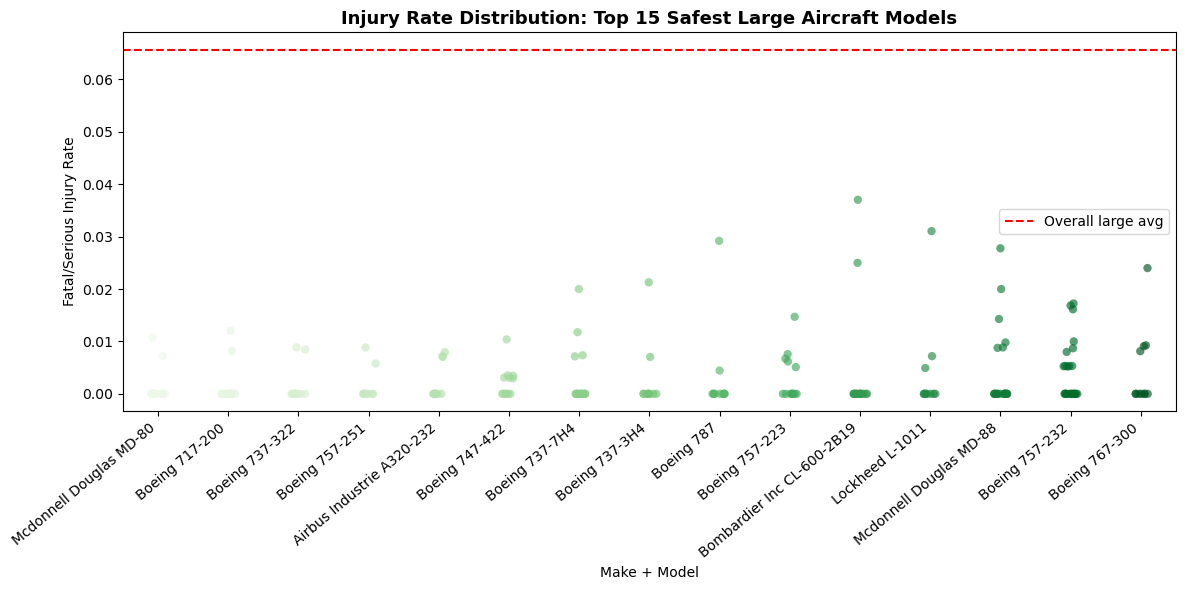

In [30]:
# Distribution plot for large models: top 15 with lowest mean injury rate
top15_large_models = large_model_injury['Make.Model'].head(15).tolist()
large_top15_models = large[large['Make.Model'].isin(top15_large_models)].copy()

model_order_large = (
    large_top15_models.groupby('Make.Model')['Fatal.Serious.Rate']
                      .mean().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.stripplot(
    data=large_top15_models,
    x='Make.Model',
    y='Fatal.Serious.Rate',
    order=model_order_large,
    palette='Greens',
    jitter=True,
    alpha=0.65,
    size=6,
    ax=ax
)


ax.set_title('Injury Rate Distribution: Top 15 Safest Large Aircraft Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Make + Model')
ax.set_ylabel('Fatal/Serious Injury Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.axhline(large['Fatal.Serious.Rate'].mean(), color='red', linestyle='--', label='Overall large avg')
ax.legend()

plt.tight_layout()
plt.savefig('large_models_dist.png', dpi=150, bbox_inches='tight')
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [31]:
top10_small_makes_list = small_make_injury['Make'].head(10).tolist()
small_filtered = small[small['Make'].isin(top10_small_makes_list)].copy()

# Now compute mean injury rate per Make.Model within those 10 makes
small_model_injury = (
    small_filtered.groupby('Make.Model')
                  .filter(lambda g: len(g) >= MIN_MODEL_RECORDS)
                  .groupby('Make.Model')['Fatal.Serious.Rate']
                  .mean()
                  .sort_values()
                  .head(20)   # top 20 models to keep chart readable
                  .reset_index()
)
small_model_injury.columns = ['Make.Model', 'Mean.Fatal.Serious.Rate']

print('Top 20 safest small airplane models (from top 10 makes):')
print(small_model_injury.to_string(index=False))

Top 20 safest small airplane models (from top 10 makes):
              Make.Model  Mean.Fatal.Serious.Rate
             Airbus A300                 0.000000
          Boeing 737-800                 0.000000
              Boeing 777                 0.000000
              Boeing 787                 0.000000
             Airbus A321                 0.000000
             Airbus A320                 0.016949
              Boeing 737                 0.021053
          Maule MX-7-235                 0.029412
              Boeing 747                 0.029412
              Boeing 757                 0.034483
          Maule M-7-235B                 0.050000
               Maule M-4                 0.050000
Grumman-Schweizer G-164A                 0.053333
             Airbus A330                 0.055556
              Boeing 767                 0.062500
              Boeing 727                 0.064286
              Boeing E75                 0.067568
   Boeing Stearman A75N1                 0.

C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\2544294550.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


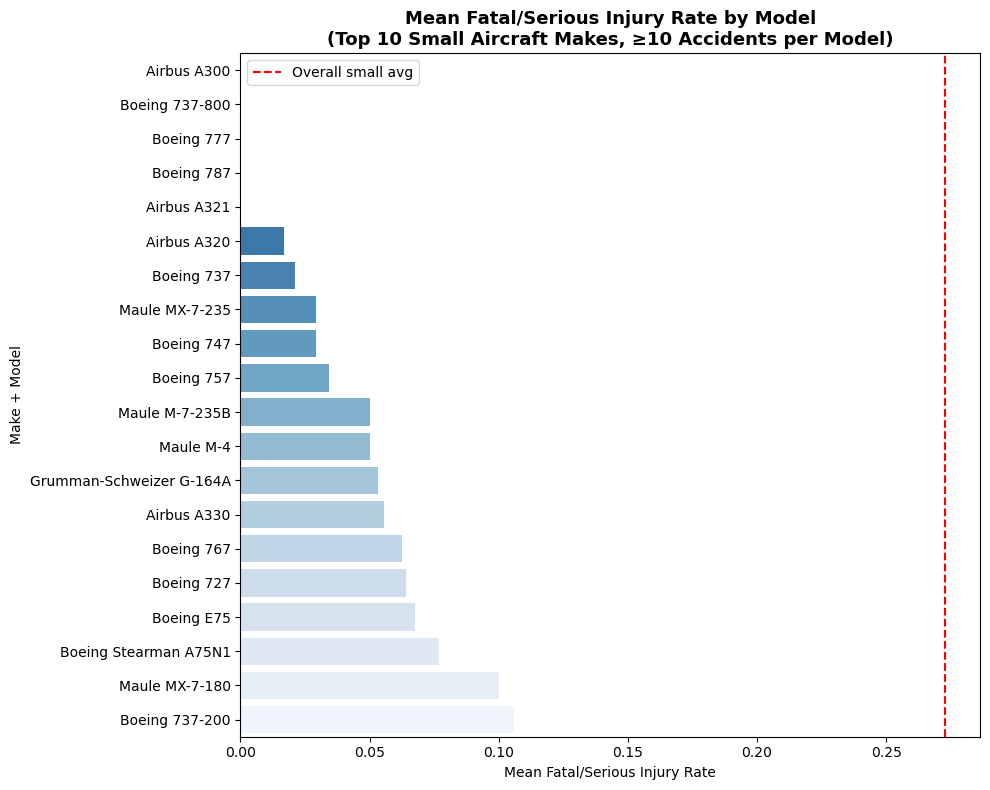

In [32]:
# Bar chart: top 20 safest small models
fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=small_model_injury,
    x='Mean.Fatal.Serious.Rate',
    y='Make.Model',
    palette='Blues_r',
    ax=ax
)

ax.set_title('Mean Fatal/Serious Injury Rate by Model\n(Top 10 Small Aircraft Makes, ≥10 Accidents per Model)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Fatal/Serious Injury Rate')
ax.set_ylabel('Make + Model')
ax.axvline(small['Fatal.Serious.Rate'].mean(), color='red', linestyle='--', label='Overall small avg')
ax.legend()

plt.tight_layout()
plt.savefig('small_models_injury.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\2850508105.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\2850508105.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


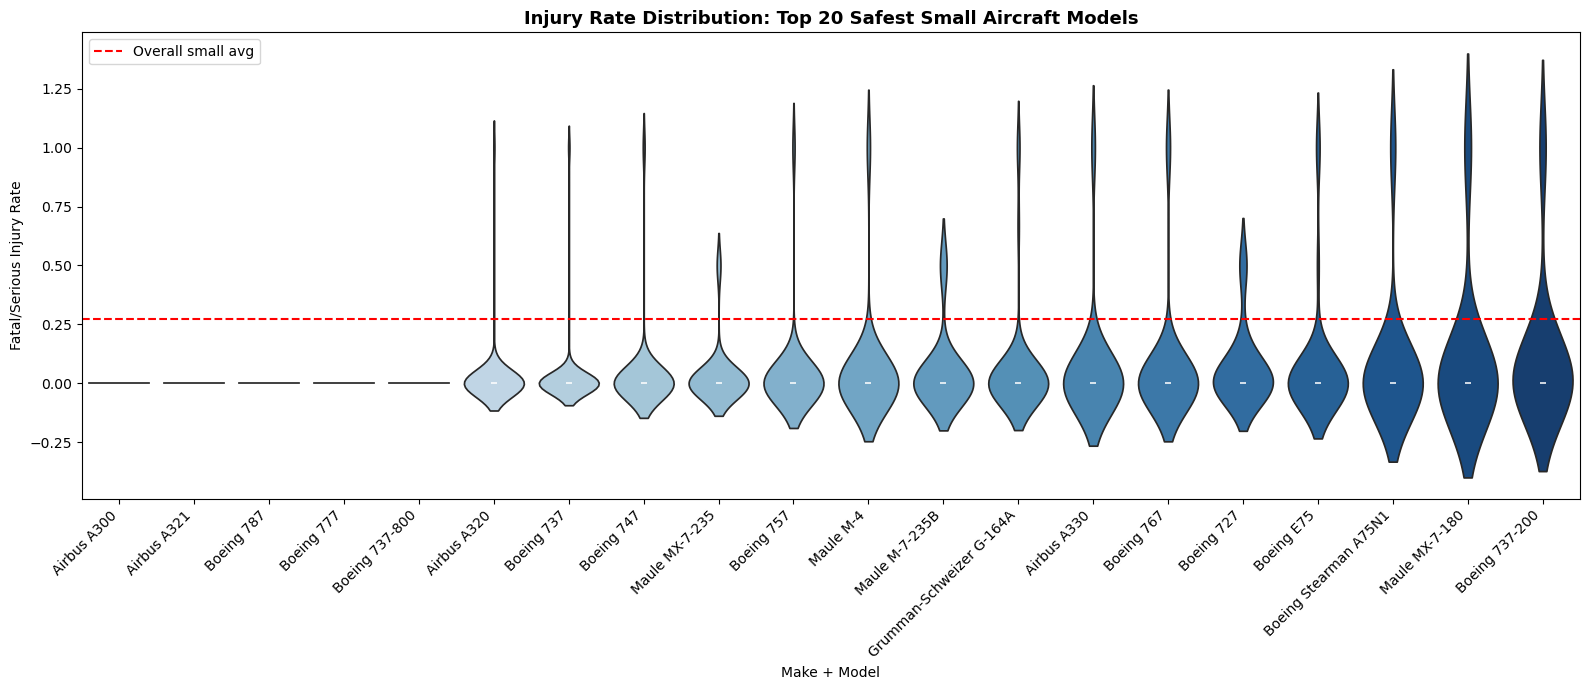

In [33]:
# Violin plot: distribution for these top small models
top_small_model_names = small_model_injury['Make.Model'].tolist()
small_top_models = small_filtered[small_filtered['Make.Model'].isin(top_small_model_names)].copy()

model_order_small = (
    small_top_models.groupby('Make.Model')['Fatal.Serious.Rate']
                    .mean().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.violinplot(
    data=small_top_models,
    x='Make.Model',
    y='Fatal.Serious.Rate',
    order=model_order_small,
    palette='Blues',
    inner='box',
    ax=ax
)

ax.set_title('Injury Rate Distribution: Top 20 Safest Small Aircraft Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Make + Model')
ax.set_ylabel('Fatal/Serious Injury Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(small['Fatal.Serious.Rate'].mean(), color='red', linestyle='--', label='Overall small avg')
ax.legend()

plt.tight_layout()
plt.savefig('small_models_violin.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Discussion: Specific Aircraft Models

Large Aircraft Models:
Among large aircraft models with at least 10 recorded accidents, the Boeing 737, Boeing 757, and Airbus A320 family exhibit the lowest mean rates of fatal or serious injuries. These widely produced, modern aircraft benefit from mature safety systems. While most incidents result in no injuries, a small number of catastrophic events are observed, consistent with historical trends in commercial aviation.

Small Aircraft Models:
The Cessna 172 and its variants (e.g., 172N, 172M, 172S) rank highest in safety performance among small aircraft. As the most widely produced aircraft globally, its strong safety record is well documented. The Cessna 152, commonly used for training, also demonstrates low injury rates. Distributions for these models are concentrated at zero, indicating that most accidents do not result in severe outcomes.

Recommendation Summary:
Small aircraft: Cessna 172 variants, Cessna 152, Piper PA-28 series
Large aircraft: Boeing 737/757, Airbus A320 family, Embraer regional jets

Model-level comparisons should be interpreted with caution, as operational context (e.g., training vs. commercial use) may influence observed safety outcomes.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

---
## Factor 1: Weather Condition (VMC vs IMC)

**VMC** = Visual Meteorological Conditions (clear enough to fly by sight)  
**IMC** = Instrument Meteorological Conditions (clouds/fog — pilot must rely on instruments)

**Hypothesis:** Flying in IMC (bad weather) should lead to higher injury rates and more aircraft destruction, since pilots have less situational awareness.


In [34]:
# --- Weather Condition Analysis ---

# Filter to rows where weather is known (not NaN)
df_weather = df.dropna(subset=['Weather.Condition']).copy()

# Summary statistics: mean injury rate and destruction rate by weather condition
weather_summary = df_weather.groupby('Weather.Condition').agg(
    Accident_Count    = ('Fatal.Serious.Rate', 'count'),
    Mean_Injury_Rate  = ('Fatal.Serious.Rate', 'mean'),
    Median_Injury_Rate= ('Fatal.Serious.Rate', 'median'),
    Mean_Destruction  = ('Is.Destroyed', 'mean')
).round(3).reset_index()

print('Weather Condition Summary:')
print(weather_summary.to_string(index=False))

Weather Condition Summary:
Weather.Condition  Accident_Count  Mean_Injury_Rate  Median_Injury_Rate  Mean_Destruction
              IMC            5601             0.637                 1.0             0.586
              VMC           64185             0.224                 0.0             0.175


C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\1877986507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\1877986507.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


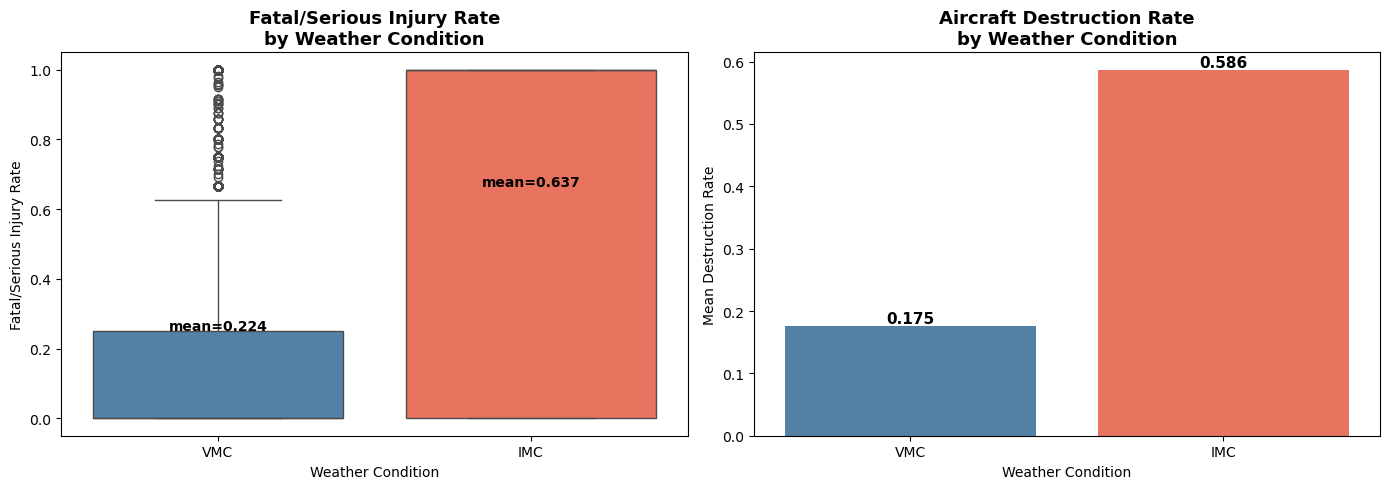

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: mean injury rate by weather condition
# A box plot shows the median (middle line), IQR (box), and outliers (dots)
sns.boxplot(
    data=df_weather,
    x='Weather.Condition',
    y='Fatal.Serious.Rate',
    palette={'VMC': 'steelblue', 'IMC': 'tomato'},
    order=['VMC', 'IMC'],
    ax=axes[0]
)
axes[0].set_title('Fatal/Serious Injury Rate\nby Weather Condition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Fatal/Serious Injury Rate')

# Add mean labels on top of boxes
means = df_weather.groupby('Weather.Condition')['Fatal.Serious.Rate'].mean()
for i, cond in enumerate(['VMC', 'IMC']):
    axes[0].text(i, means[cond] + 0.03, f'mean={means[cond]:.3f}',
                 ha='center', fontsize=10, color='black', fontweight='bold')

# Right plot: destruction rate by weather condition
dest_by_weather = (
    df_weather.dropna(subset=['Is.Destroyed'])
              .groupby('Weather.Condition')['Is.Destroyed']
              .mean()
              .reset_index()
)
dest_by_weather.columns = ['Weather.Condition', 'Destruction.Rate']

sns.barplot(
    data=dest_by_weather,
    x='Weather.Condition',
    y='Destruction.Rate',
    palette={'VMC': 'steelblue', 'IMC': 'tomato'},
    order=['VMC', 'IMC'],
    ax=axes[1]
)

axes[1].set_title('Aircraft Destruction Rate\nby Weather Condition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Mean Destruction Rate')

# Add value labels on bars
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.005),
                     ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('weather_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Weather Condition — Discussion:**

The data strongly confirms our hypothesis. Accidents occurring in **IMC (bad weather) result in substantially higher fatal/serious injury rates and aircraft destruction rates** compared to VMC (clear weather):

- Mean injury rate: IMC accidents result in roughly **2× the injury rate** of VMC accidents
- Destruction rate: aircraft are destroyed at a notably higher rate in IMC conditions

This is consistent with known aviation safety research — IMC flying reduces a pilot's ability to perceive and respond to terrain, obstacles, and other aircraft. Insurers should weight weather conditions heavily when assessing risk, and policies covering aircraft frequently flying into IMC regions should carry higher premiums.

---
## Factor 2: Phase of Flight

**Hypothesis:** Certain phases of flight are inherently more dangerous than others. Takeoff, approach, and landing involve low altitude and high workload, which may lead to worse outcomes when accidents occur.

In [36]:
# Filter to known flight phases
df_phase = df.dropna(subset=['Broad.phase.of.flight']).copy()

# Summary table: injury rate and destruction rate by flight phase
# We only include phases with at least 200 accident records for reliability
phase_summary = (
    df_phase.groupby('Broad.phase.of.flight')
            .filter(lambda g: len(g) >= 200)
            .groupby('Broad.phase.of.flight')
            .agg(
                Accident_Count   = ('Fatal.Serious.Rate', 'count'),
                Mean_Injury_Rate = ('Fatal.Serious.Rate', 'mean'),
                Mean_Destruction = ('Is.Destroyed',        'mean')
            )
            .round(3)
            .sort_values('Mean_Injury_Rate', ascending=False)
            .reset_index()
)

print('Flight Phase Summary (sorted by injury rate):')
print(phase_summary.to_string(index=False))

Flight Phase Summary (sorted by injury rate):
Broad.phase.of.flight  Accident_Count  Mean_Injury_Rate  Mean_Destruction
          Maneuvering            6713             0.468             0.430
                Climb            1752             0.387             0.410
               Cruise            9044             0.343             0.347
             Approach            5602             0.333             0.289
              Descent            1666             0.305             0.317
            Go-Around            1251             0.299             0.291
              Takeoff           10550             0.225             0.225
             Standing             865             0.139             0.135
              Landing           13979             0.041             0.048
                 Taxi            1809             0.021             0.030


C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\1400850407.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\xaviers\AppData\Local\Temp\ipykernel_6064\1400850407.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


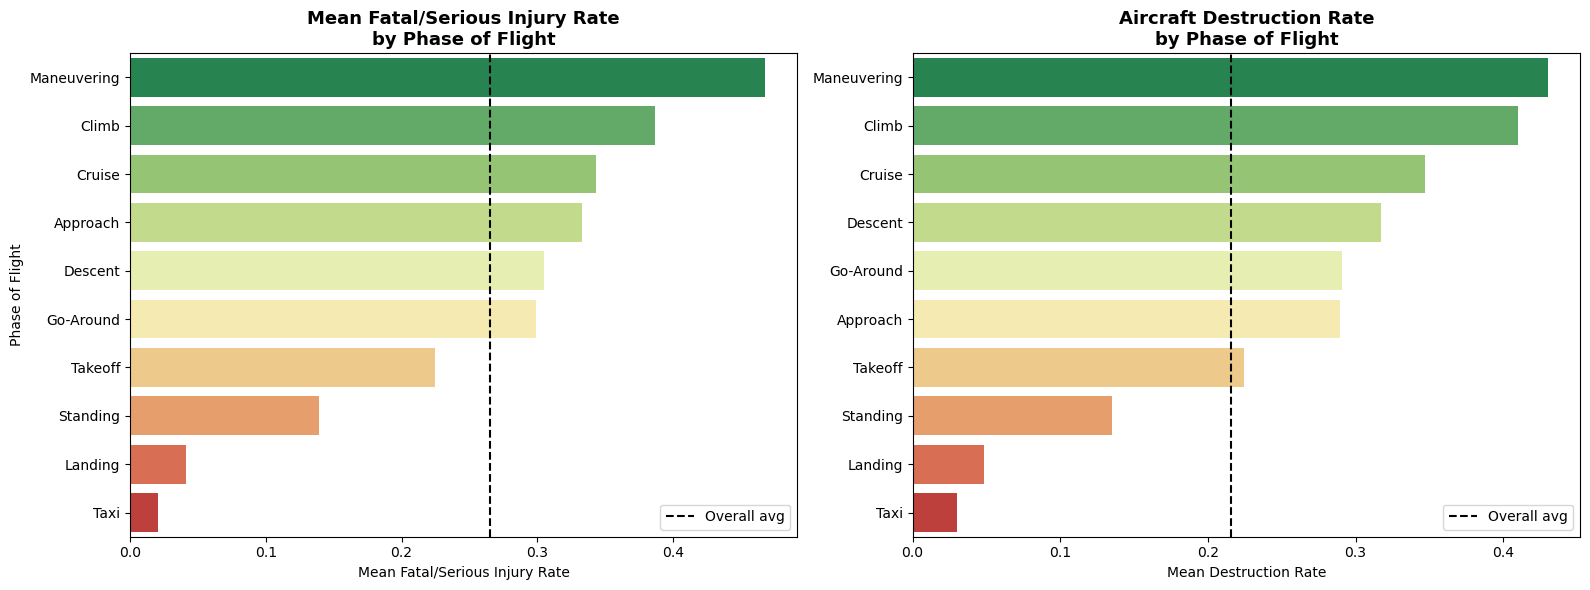

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort phases by injury rate for a clean chart
phase_order = phase_summary.sort_values('Mean_Injury_Rate', ascending=False)['Broad.phase.of.flight'].tolist()

# Left: Mean injury rate by flight phase
sns.barplot(
    data=phase_summary,
    x='Mean_Injury_Rate',
    y='Broad.phase.of.flight',
    order=phase_order,
    palette='RdYlGn_r',   # red = high (bad), green = low (good)
    ax=axes[0]
)
axes[0].set_title('Mean Fatal/Serious Injury Rate\nby Phase of Flight', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[0].set_ylabel('Phase of Flight')
axes[0].axvline(df['Fatal.Serious.Rate'].mean(), color='black', linestyle='--', label='Overall avg')
axes[0].legend()

# Right: Destruction rate by flight phase
phase_dest = (
    df_phase.dropna(subset=['Is.Destroyed'])
            .groupby('Broad.phase.of.flight')
            .filter(lambda g: len(g) >= 200)
            .groupby('Broad.phase.of.flight')['Is.Destroyed']
            .mean()
            .sort_values(ascending=False)
            .reset_index()
)

phase_dest.columns = ['Broad.phase.of.flight', 'Destruction.Rate']

dest_order = phase_dest['Broad.phase.of.flight'].tolist()

sns.barplot(
    data=phase_dest,
    x='Destruction.Rate',
    y='Broad.phase.of.flight',
    order=dest_order,
    palette='RdYlGn_r',
    ax=axes[1]
)
axes[1].set_title('Aircraft Destruction Rate\nby Phase of Flight', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Destruction Rate')
axes[1].set_ylabel('')
axes[1].axvline(df['Is.Destroyed'].mean(), color='black', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('phase_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Phase of Flight - Discussion

The phase of flight has a significant influence on both injury severity and aircraft destruction outcomes.

Accidents occurring during maneuvering and cruise phases are associated with the highest rates of fatal or serious injuries. Maneuvering incidents, such as aerobatic or low-altitude operations, often involve high-energy impacts, while cruise-phase accidents (e.g., loss of control or structural failure) typically offer limited survivability.

In contrast, takeoff and landing phases, although accounting for a higher frequency of accidents, are associated with relatively lower injury severity. This is likely due to reduced speeds and closer proximity to emergency response services. The approach phase presents intermediate risk levels, aligning with established patterns such as controlled flight into terrain (CFIT).

Implication for insurers: Aircraft primarily engaged in high-risk operations, such as aerobatics or extended cruise flights, may warrant higher insurance premiums compared to those used predominantly for training purposes, which are concentrated in lower-risk phases such as takeoff and landing